In [8]:
from diffrax import diffeqsolve, ODETerm,ControlTerm
from jax.scipy.stats import norm
import diffrax
import jax.numpy as jnp
import numpy as np
import jax
import matplotlib.pyplot as plt

In [9]:

t_vec = jnp.linspace(0,1,100)

def lorenz_drift(t,X,args):
  F,_ = args

  return (jnp.roll(X, -1) - jnp.roll(X, 2)) * jnp.roll(X, 1) - X + F 


def lorenz_diffusion(t,X,args):

  _,noise = args

  return noise * jnp.eye(len(X))

In [10]:
'''The model integrator. Takes the length of time to integrate, the initial condition,prng key, and a parameter vector.'''
def model(ts,y0,par,key):
  key,w_key = jax.random.split(key)
  brownian_motion = diffrax.VirtualBrownianTree(ts[0],ts[-1], tol=1e-3, shape=(len(y0),), key=w_key)
  terms = diffrax.MultiTerm(ODETerm(lorenz_drift), ControlTerm(lorenz_diffusion, brownian_motion))

  solution = diffrax.diffeqsolve(
            terms,
            diffrax.Heun(),
            t0=ts[0],
            t1=ts[-1],
            dt0=ts[1] - ts[0],
            y0=y0,
            args=par,
            saveat=diffrax.SaveAt(ts=ts),
              #At which points to save the output
        )
  return solution.ys


noise = 1.
key = jax.random.key(0)
key,sim_key = jax.random.split(key)
num_variables = 20
F = 8.

key,init_key = jax.random.split(key)
IC = jax.random.multivariate_normal(init_key,mean = jnp.zeros(num_variables),cov = jnp.eye(num_variables))

print(IC)

'''Simulate model'''
X_true = model(t_vec,y0 = IC,par = (F,noise),key = sim_key)

[-1.2574775  -0.4016044  -1.1213602   0.87837774 -0.86175495  0.34651348
  0.9404431  -0.12234341 -1.1891836   0.07152013 -1.7588533  -1.0268484
  1.0308878  -0.00312373  0.01677057  0.04222    -2.6004884   0.00873749
  0.83860636 -0.08322488]


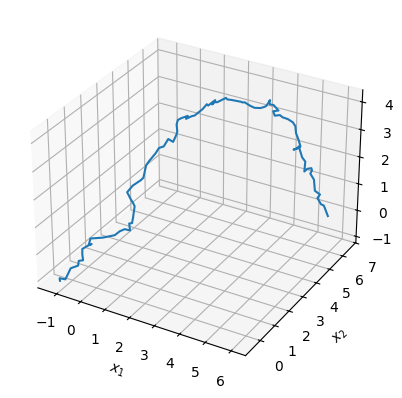

In [11]:
X = np.array(X_true)

# Plot the first three variables
fig = plt.figure()
ax = fig.add_subplot(projection="3d")
ax.plot(X[:, 0], X[:, 1], X[:, 2])
ax.set_xlabel("$x_1$")
ax.set_ylabel("$x_2$")
ax.set_zlabel("$x_3$")
plt.show()

In [12]:
'''Construct the observation operator'''
def OBS_OP(spacing,num_vars): 
    rows = num_vars//spacing
    HS = []
    
    one_hot_elem = 0
    for index in range(rows): 
        temp = jnp.zeros(num_vars)
        temp = temp.at[one_hot_elem].set(1)
        HS.append(temp)
        one_hot_elem += spacing

    return jnp.array(HS)



In [13]:
'''Observations will be every 5th variable'''
H = OBS_OP(5,num_variables)
OBS = X_true.T

OBS = (H @ OBS).reshape(-1)

R_obs = jnp.eye(len(OBS))

key,noise_key = jax.random.split(key)
OBS += jax.random.multivariate_normal(noise_key,jnp.zeros(len(OBS)),R_obs).T

print(OBS.shape)

(400,)


In [ ]:
L = 500
step_size = 0.01
num_ensemble_members = 1000

key, init_ensemble_key = jax.random.split(key)
ensemble = jax.random.multivariate_normal(
    init_ensemble_key,
    mean=jnp.zeros(num_variables),
    cov=jnp.eye(num_variables),
    shape=(num_ensemble_members,),
)

for iter in range(L):
    sim_key, key = jax.random.split(key)
    sim_keys = jax.random.split(sim_key, num_ensemble_members)

    sim_X = jax.vmap(model, in_axes=(None, 0, None, 0))(
        t_vec, ensemble, (F, noise), sim_keys
    )
    sim_obs = jax.vmap(jnp.matmul, in_axes=(None, 0))(
        H, jnp.swapaxes(sim_X, 1, 2)
    ).reshape((num_ensemble_members, -1))

    c_xx = jnp.cov(ensemble.T)

    ensemble_mean = jnp.mean(ensemble, axis=0)
    sim_obs_mean = jnp.mean(sim_obs, axis=0)

    ensemble_anomalies = ensemble - ensemble_mean
    obs_anomalies = sim_obs - sim_obs_mean

    C_xx = jnp.cov(ensemble.T)
    C_xy = 1 / (num_ensemble_members - 1) * ensemble_anomalies.T @ obs_anomalies

    epsilon = 1.2
    C_yy = jnp.cov(sim_obs.T) + jnp.eye(sim_obs.shape[1]) * epsilon

    S = C_xy @ jnp.linalg.pinv(C_yy + R_obs) 

    def member_update(member,member_obs): 
        y_true = OBS.ravel()
        y_sim  = member_obs.ravel()
        innovation = y_true - y_sim
        update_term = jnp.dot(S, innovation)
        return member + step_size * update_term
    ensemble = jax.vmap(member_update,in_axes = (0,0))(ensemble,sim_obs)
    
    print(f"Step {iter}, abs_err: {jnp.sum(jnp.abs(jnp.mean(ensemble,axis = 0) - IC))}")
    

Step 0, abs_err: 14.516678810119629
Step 1, abs_err: 14.48005485534668
Step 2, abs_err: 14.447616577148438
Step 3, abs_err: 14.427389144897461
Step 4, abs_err: 14.40562915802002
Step 5, abs_err: 14.383535385131836
Step 6, abs_err: 14.373323440551758
Step 7, abs_err: 14.35861873626709
Step 8, abs_err: 14.346035957336426
Step 9, abs_err: 14.339212417602539
Step 10, abs_err: 14.326940536499023
Step 11, abs_err: 14.318552017211914
Step 12, abs_err: 14.304429054260254
Step 13, abs_err: 14.296343803405762
Step 14, abs_err: 14.28464126586914
Step 15, abs_err: 14.277387619018555
Step 16, abs_err: 14.264784812927246
Step 17, abs_err: 14.25257682800293
Step 18, abs_err: 14.241731643676758
Step 19, abs_err: 14.235391616821289
Step 20, abs_err: 14.228531837463379
Step 21, abs_err: 14.215746879577637
Step 22, abs_err: 14.205220222473145
Step 23, abs_err: 14.197857856750488
Step 24, abs_err: 14.185930252075195
Step 25, abs_err: 14.17469310760498
Step 26, abs_err: 14.162652969360352
Step 27, abs_err: